In [1]:
# Importing the necessary Libraries
import os
import pandas as pd
from pathlib import Path
from model import predict_outcome
import random

In [2]:
# Loading the previous results and goalscorers 

base_dir = Path.cwd()
while base_dir.name != "World Cup Predictor":
    base_dir = base_dir.parent
ts_path = base_dir/"data"/"processed"/"team_strength.csv"
fixtures_path = base_dir/"data"/"processed"/"fixtures_group_stage.csv"
ts_df = pd.read_csv(ts_path, index_col='team')
fixtures_df = pd.read_csv(fixtures_path)

name_mapping = {
    'Czechia': 'Czech Republic',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',
    'Cape Verde Islands': 'Cape Verde',
    'Congo DR': 'DR Congo'
}

fixtures_df['home'] = fixtures_df['home'].replace(name_mapping)
fixtures_df['away'] = fixtures_df['away'].replace(name_mapping)

In [3]:
# Creating a dictionary to store the points for each team and grouping the fixtures based on actual Groups

teams = fixtures_df['home'].unique().tolist()

points = dict()
for team in teams:
    points[str(team)] = 0
print(f"Points: \n{points}")

grouped_fixtures_df = fixtures_df.groupby('group')
print(fixtures_df['group'].unique())

Points: 
{'Mexico': 0, 'South Korea': 0, 'Canada': 0, 'United States': 0, 'Qatar': 0, 'Brazil': 0, 'Haiti': 0, 'Australia': 0, 'Germany': 0, 'Netherlands': 0, 'Ivory Coast': 0, 'Sweden': 0, 'Spain': 0, 'Belgium': 0, 'Saudi Arabia': 0, 'Iran': 0, 'France': 0, 'Iraq': 0, 'Argentina': 0, 'Austria': 0, 'Portugal': 0, 'England': 0, 'Ghana': 0, 'Uzbekistan': 0, 'Czech Republic': 0, 'Switzerland': 0, 'Scotland': 0, 'Turkey': 0, 'Ecuador': 0, 'Tunisia': 0, 'Uruguay': 0, 'New Zealand': 0, 'Norway': 0, 'Jordan': 0, 'Panama': 0, 'Colombia': 0, 'Bosnia and Herzegovina': 0, 'Morocco': 0, 'South Africa': 0, 'Curaçao': 0, 'Japan': 0, 'Paraguay': 0, 'Senegal': 0, 'Cape Verde': 0, 'Egypt': 0, 'Croatia': 0, 'DR Congo': 0, 'Algeria': 0}
<StringArray>
['GROUP_A', 'GROUP_B', 'GROUP_D', 'GROUP_C', 'GROUP_E', 'GROUP_F', 'GROUP_H',
 'GROUP_G', 'GROUP_I', 'GROUP_J', 'GROUP_K', 'GROUP_L']
Length: 12, dtype: str


In [4]:
# Precomputing the outcomes of all possible different matchups to avoid repetitive calculation and save time
precomputed = dict()
for home in teams:
    for away in teams:
        if home != away:
            precomputed[(home, away)] = predict_outcome(home, away)

print(f"Precomputed {len(precomputed)} matchups")

def group_stage(fixtures, points, precomputed):
    group_winners = dict()
    group_runners_up = dict()
    third_place = []
    for group_name, group_matches in fixtures:
        group_teams = pd.concat([group_matches['home'],group_matches['away']]).unique().tolist()        
        for _,match in group_matches.iterrows():
            p_home, p_away, p_draw = precomputed[(match['home'],match['away'])]
            # This is a predicted points method which gives the same 32 teams going through for all the 10k simulations which is not realistic
            # points[match['home']] += 3*p_home + p_draw
            # points[match['away']] += 3*p_away + p_draw
            # Introducing a random number method to introduce some jeopardy and unpredictibility in the group stage too
            r = random.random()
            if r < p_home:
                points[match['home']] += 3
            elif r< p_home + p_draw:
                points[match['home']] += 1
                points[match['away']] += 1
            else:
                points[match['away']] += 3
        group_points = dict()
        for team in group_teams:
            group_points[str(team)] = points[str(team)]
        sorted_points = dict(
            sorted(group_points.items(), key=lambda x: x[1], reverse=True)
        )
        sorted_keys = list(sorted_points.keys())
        group_winners[group_name] = sorted_keys[0]
        group_runners_up[group_name] = sorted_keys[1]
        third_place.append((sorted_keys[2], list(sorted_points.values())[2]))

    sorted_third_place = sorted(third_place, key=lambda x: x[1], reverse=True)[:8]
    third_place_teams = [team for team, points in sorted_third_place]
    
    return group_winners, group_runners_up,third_place_teams

Precomputed 2256 matchups


In [5]:
# Debug check
print("--- predict_outcome test ---")
print("Brazil vs Haiti:", predict_outcome('Brazil', 'Haiti'))
print("Germany vs Curaçao:", predict_outcome('Germany', 'Curaçao'))
print()
print("--- ts_df values ---")
print(ts_df.loc[['Brazil', 'Germany', 'Haiti', 'Curaçao']])

--- predict_outcome test ---
Brazil vs Haiti: (np.float64(0.874740806448663), np.float64(0.020971422788243953), np.float64(0.10414651482739451))
Germany vs Curaçao: (np.float64(0.93487936003306), np.float64(0.010780025206744901), np.float64(0.05267399116510613))

--- ts_df values ---
         goals_for  goals_against
team                             
Brazil    2.296759       0.717796
Germany   3.074821       0.975703
Haiti     0.432713       1.198137
Curaçao   0.370551       1.212475


In [6]:
gw, gru, tp = group_stage(grouped_fixtures_df,points, precomputed)
print(gw)
print(gru)
print(tp)

{'GROUP_A': 'Mexico', 'GROUP_B': 'Switzerland', 'GROUP_C': 'Brazil', 'GROUP_D': 'United States', 'GROUP_E': 'Germany', 'GROUP_F': 'Japan', 'GROUP_G': 'Belgium', 'GROUP_H': 'Uruguay', 'GROUP_I': 'Senegal', 'GROUP_J': 'Argentina', 'GROUP_K': 'Portugal', 'GROUP_L': 'Panama'}
{'GROUP_A': 'South Korea', 'GROUP_B': 'Qatar', 'GROUP_C': 'Morocco', 'GROUP_D': 'Australia', 'GROUP_E': 'Ecuador', 'GROUP_F': 'Netherlands', 'GROUP_G': 'Iran', 'GROUP_H': 'Saudi Arabia', 'GROUP_I': 'Norway', 'GROUP_J': 'Algeria', 'GROUP_K': 'Colombia', 'GROUP_L': 'Croatia'}
['Bosnia and Herzegovina', 'Egypt', 'Ghana', 'Paraguay', 'Curaçao', 'Tunisia', 'France', 'Czech Republic']


In [7]:
# Instead of always picking the higher probability team, sample randomly based on the probabilities.

# The logic:
# 1. Generate a random number between 0 and 1 using random.random()
# 2. If it falls below p_home → home wins
# 3. If it falls below p_home + p_draw → it's a draw, but since this is a
# knockout, away team wins on penalties (just return away)
# 4. Otherwise → away wins

def get_winner(home,away, precomputed):
    p_home, p_away, p_draw = precomputed[(home,away)]
    num = random.random()
    if num < p_home:
        return home
    elif num < p_home + p_draw:
        return random.choice([home, away])
    else:
        return away

#### How the Round of 32 and beyond works: 

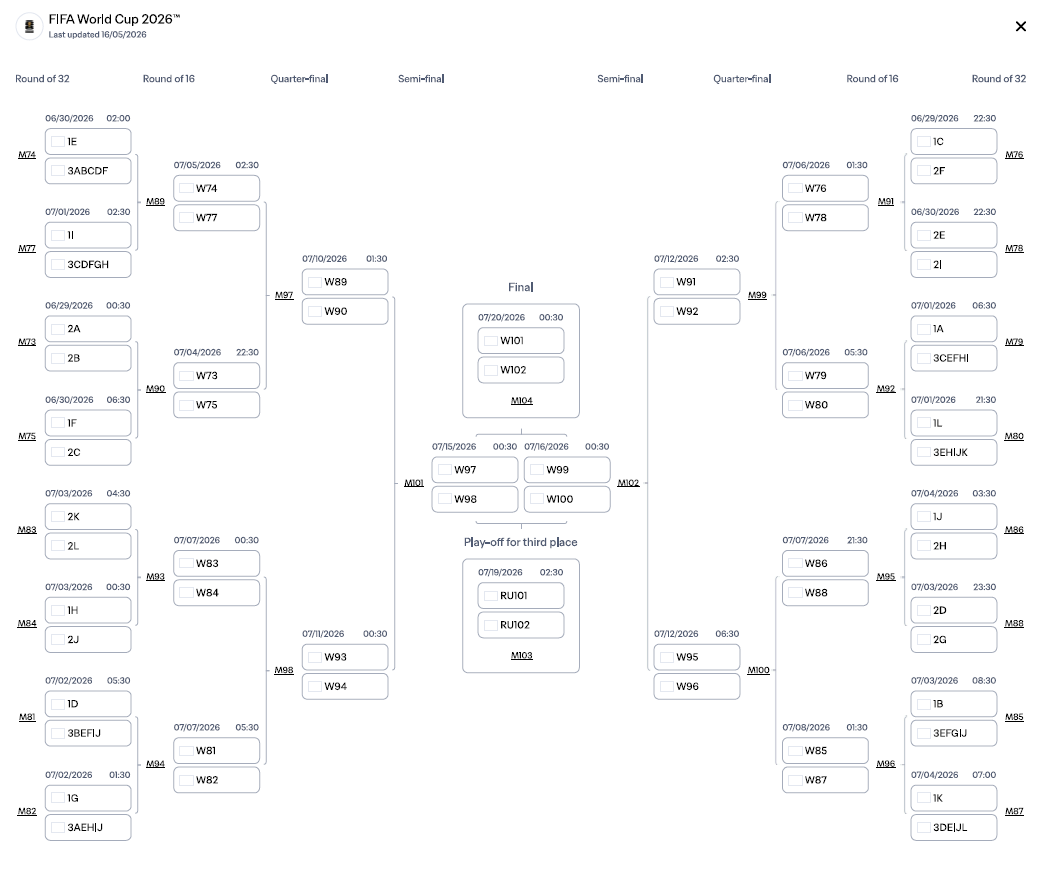

##### Here's what the bracket tells us. The notation means:
> - 1E = Group E winner, 2A = Group A runner-up
> - 3ABCDF = best 3rd place team from groups A, B, C, D, or F

##### Round of 32 matchups (deterministic parts):
- 2A vs 2B
- 1F vs 2C
- 1E vs 3ABCDF
- 1I vs 3CDFGH
- 2K vs 2L
- 1H vs 2J
- 1D vs 3BEFIJ
- 1G vs 3AEHIJ
- 1C vs 2F
- 2E vs 2I
- 1A vs 3CEFHI
- 1L vs 3EHIJK
- 1J vs 2H
- 2D vs 2G
- 1B vs 3EFGIJ
- 1K vs 3DEIJL

- The 3rd place slots are complex. The specific slot depends on which 8
groups contribute 3rd place teams, and FIFA has pre-defined rules for each
combination. This is too complex for the base model.

- **Approach:** Hardcode the 1st vs 2nd matchups exactly as above, and randomly assign the 8 best 3rd place teams to the 8 third-place slots. That gives you a realistic bracket structure without the full complexity.

In [8]:
# Function to build bracket according to the logic described above
def build_bracket(group_winners, group_runners_up, third_place_teams):
    # randomly shuffling the 8 third-placed teams
    random.shuffle(third_place_teams)

    # making a dictionary to map all third place teams to the index number 1-8
    tp_teams = dict()
    for i, team in enumerate(third_place_teams):
        tp_teams[f'tp{i+1}'] = team

    # changing the key of the dictionary from 'GROUP A' to w_A/ru_A for winners/runners up.
    winners = {}
    for group, team in group_winners.items():
        letter = group.split('_')[1]    
        new_key = f'w_{letter}'    
        winners[new_key] = team

    runner_ups = {}
    for group, team in group_runners_up.items():
        letter = group.split('_')[1]    
        new_key = f'ru_{letter}'    
        runner_ups[new_key] = team

    # Pre-defined bracket of Round of 32 matches
    round_of_32 = [(runner_ups['ru_A'], runner_ups['ru_B']), (winners['w_F'], runner_ups['ru_C']), (winners['w_E'], tp_teams['tp1']), (winners['w_I'], tp_teams['tp2']),
                   (runner_ups['ru_K'], runner_ups['ru_L']), (winners['w_H'], runner_ups['ru_J']), (winners['w_D'], tp_teams['tp3']), (winners['w_G'], tp_teams['tp4']),
                   (winners['w_C'], runner_ups['ru_F']), (runner_ups['ru_E'], runner_ups['ru_I']), (winners['w_A'], tp_teams['tp5']), (winners['w_L'], tp_teams['tp6']),
                   (winners['w_J'], runner_ups['ru_H']), (runner_ups['ru_D'], runner_ups['ru_G']), (winners['w_B'], tp_teams['tp7']), (winners['w_K'], tp_teams['tp8'])]

    return round_of_32

In [9]:
bracket = build_bracket(gw, gru, tp)
print(len(bracket))
print(bracket)

16
[('South Korea', 'Qatar'), ('Japan', 'Morocco'), ('Germany', 'Ghana'), ('Senegal', 'France'), ('Colombia', 'Croatia'), ('Uruguay', 'Algeria'), ('United States', 'Curaçao'), ('Belgium', 'Czech Republic'), ('Brazil', 'Netherlands'), ('Ecuador', 'Norway'), ('Mexico', 'Bosnia and Herzegovina'), ('Panama', 'Paraguay'), ('Argentina', 'Saudi Arabia'), ('Australia', 'Iran'), ('Switzerland', 'Egypt'), ('Portugal', 'Tunisia')]


In [10]:
# Converting the bracket into a flat list
round_of_32 = [team for matchup in bracket for team in matchup]

# Defining a function to run the knockout stages of the tournament
def run_knockout_round(bracket_teams, precomputed):
    round_winners = []
    for i in range(0, len(bracket_teams), 2):
        winner = get_winner(bracket_teams[i],bracket_teams[i+1],precomputed)
        round_winners.append(winner)

    return round_winners

In [11]:
# Simulating the knockout stages
round_of_16 = run_knockout_round(round_of_32,precomputed)
print(f"Round of 16:\n{round_of_16}")
quarter_finals = run_knockout_round(round_of_16,precomputed)
print(f"Quarter-Finals:\n{quarter_finals}")
semi_finals = run_knockout_round(quarter_finals,precomputed)
print(f"Semi-Finals:\n{semi_finals}")
final = run_knockout_round(semi_finals,precomputed)
print(f"Final:\n{final}\n")
champions = run_knockout_round(final,precomputed)
print(f"Champions: {champions}")

Round of 16:
['South Korea', 'Morocco', 'Germany', 'France', 'Croatia', 'Algeria', 'United States', 'Belgium', 'Netherlands', 'Norway', 'Mexico', 'Paraguay', 'Argentina', 'Australia', 'Switzerland', 'Tunisia']
Quarter-Finals:
['South Korea', 'Germany', 'Algeria', 'Belgium', 'Norway', 'Mexico', 'Australia', 'Switzerland']
Semi-Finals:
['South Korea', 'Algeria', 'Mexico', 'Australia']
Final:
['South Korea', 'Mexico']

Champions: ['South Korea']


#### Monte Carlo Wrapper

##### Simulating the tournament 10,000 times to get probability of which team is most likely to win the FIFA World Cup 2026

In [12]:
# Creating a dictionary to keep count of how many times a particular team won the tournament in the simulation
win_counts = {team:0 for team in teams}

In [13]:
from tqdm import tqdm

for _ in tqdm(range(10000)):
    # Resetting the points to 0 for every simulation
    points = {team:0 for team in teams}

    # Getting the group winners, group runner-ups and 8 3rd place teams that will go through
    gw, gru, tp = group_stage(grouped_fixtures_df, points, precomputed)
    
    # Building the bracket for Knockout Stages
    bracket = build_bracket(gw,gru,tp)
    ro32 = [team for matchup in bracket for team in matchup]

    # Round of 32
    ro16 = run_knockout_round(ro32, precomputed)

    # Round of 16
    quarters = run_knockout_round(ro16, precomputed)

    # Quarter-finals
    semis = run_knockout_round(quarters, precomputed)
    
    # Sem-finals
    final = run_knockout_round(semis, precomputed)
    
    # Final
    champions = run_knockout_round(final, precomputed)
    
    # Updating the winners count dictionary
    win_counts[champions[0]] += 1

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:16<00:00, 131.08it/s]


In [14]:
df_predictions = pd.DataFrame.from_dict(win_counts, orient='index',
columns=['wins'])
df_predictions = df_predictions.sort_values('wins', ascending=False)
df_predictions['win_probability'] = df_predictions['wins'] / 10000
df_predictions.to_csv(base_dir/"outputs"/"predictions.csv")
print(df_predictions.head(10))

               wins  win_probability
Morocco        1399           0.1399
Portugal       1392           0.1392
Germany         969           0.0969
Brazil          792           0.0792
Belgium         684           0.0684
Netherlands     656           0.0656
Japan           576           0.0576
Senegal         550           0.0550
Argentina       542           0.0542
United States   412           0.0412
